In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# Path to your zip file in Google Drive
zip_path = '/content/drive/MyDrive/PetImages.zip'
extract_path = '/content/PetImages'

# Unzip only if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
import os
from PIL import Image

def remove_corrupted_images(folder):
    num_deleted = 0
    for category in ["cat", "dog"]:
        folder_path = os.path.join(folder, category)
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Verify that it is, in fact, an image
            except (IOError, SyntaxError):
                os.remove(file_path)
                num_deleted += 1
    print(f"Deleted {num_deleted} corrupted images from {folder}")

remove_corrupted_images('/content/PetImages/train')
remove_corrupted_images('/content/PetImages/test')


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Deleted 0 corrupted images from /content/PetImages/train
Deleted 0 corrupted images from /content/PetImages/test


In [4]:
import os
from PIL import Image

def aggressively_clean_images(folder):
    """Aggressively clean and convert ALL images to RGB"""
    num_deleted = 0
    num_converted = 0
    num_checked = 0
    
    for category in ["cat", "dog"]:
        folder_path = os.path.join(folder, category)
        files_to_delete = []
        
        for filename in os.listdir(folder_path):
            if filename.startswith('.'):
                files_to_delete.append(filename)
                continue
                
            file_path = os.path.join(folder_path, filename)
            
            try:
                # Open and check image
                img = Image.open(file_path)
                num_checked += 1
                
                # Convert to RGB no matter what
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                    img.save(file_path, 'JPEG', quality=95)
                    num_converted += 1
                    
            except Exception as e:
                # Delete any file that causes an error
                files_to_delete.append(filename)
        
        # Delete all problematic files
        for filename in files_to_delete:
            file_path = os.path.join(folder_path, filename)
            try:
                os.remove(file_path)
                num_deleted += 1
            except:
                pass
    
    print(f"\n{folder} Statistics:")
    print(f"  Checked: {num_checked} images")
    print(f"  Converted to RGB: {num_converted} images")
    print(f"  Deleted: {num_deleted} invalid/system files")

# Aggressively clean and convert all images
print("Starting aggressive image cleaning...")
aggressively_clean_images('/content/PetImages/train')
aggressively_clean_images('/content/PetImages/test')
print("\nImage cleaning complete! All images are now RGB format.")


Starting aggressive image cleaning...

/content/PetImages/train Statistics:
  Checked: 20031 images
  Converted to RGB: 0 images
  Deleted: 0 invalid/system files

/content/PetImages/test Statistics:
  Checked: 4967 images
  Converted to RGB: 0 images
  Deleted: 0 invalid/system files

Image cleaning complete! All images are now RGB format.


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization,Dropout

In [6]:
import tensorflow as tf
from tensorflow import keras
import os

def find_and_delete_bad_images(folder):
    """Test each image file directly without loading dataset"""
    print(f"\nScanning {folder}...")
    
    bad_files = []
    
    # Get list of all files and try each individually
    for category in ["cat", "dog"]:
        folder_path = os.path.join(folder, category)
        if not os.path.exists(folder_path):
            print(f"Directory {folder_path} does not exist")
            continue
            
        for filename in os.listdir(folder_path):
            if filename.startswith('.'):
                continue
            
            file_path = os.path.join(folder_path, filename)
            
            try:
                # Read file with TensorFlow
                img_string = tf.io.read_file(file_path)
                
                # Try JPEG decode
                try:
                    decoded = tf.image.decode_jpeg(img_string)
                except:
                    # Try PNG decode
                    try:
                        decoded = tf.image.decode_png(img_string)
                    except:
                        # Try GIF or other formats
                        try:
                            decoded = tf.image.decode_image(img_string)
                        except:
                            # Can't decode with any method
                            bad_files.append(file_path)
                            print(f"Bad file: {filename}")
            except Exception as e:
                bad_files.append(file_path)
                print(f"Error reading {filename}: {str(e)[:50]}")
    
    # Delete bad files
    deleted_count = 0
    for file_path in bad_files:
        try:
            os.remove(file_path)
            deleted_count += 1
        except:
            pass
    
    print(f"Removed {deleted_count} corrupted images from {folder}")
    return deleted_count

# Scan and clean - NO dataset loading yet
print("=" * 60)
print("FINDING AND REMOVING BAD IMAGES")
print("=" * 60)
train_removed = find_and_delete_bad_images('/content/PetImages/train')
test_removed = find_and_delete_bad_images('/content/PetImages/test')

print("\n" + "=" * 60)
print("LOADING CLEANED DATASETS")
print("=" * 60)

train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/PetImages/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    seed=42
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/PetImages/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    seed=42
)

print("\nDatasets loaded successfully!")
print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(validation_ds)}")


FINDING AND REMOVING BAD IMAGES

Scanning /content/PetImages/train...
Bad file: 4351.jpg
Bad file: 2317.jpg
Bad file: 9500.jpg
Bad file: 2494.jpg
Removed 4 corrupted images from /content/PetImages/train

Scanning /content/PetImages/test...
Bad file: 10404.jpg
Bad file: 11233.jpg
Bad file: 11912.jpg
Removed 3 corrupted images from /content/PetImages/test

LOADING CLEANED DATASETS
Found 20027 files belonging to 2 classes.
Found 4964 files belonging to 2 classes.

Datasets loaded successfully!
Train batches: 626
Validation batches: 156


In [16]:
from tensorflow.keras import Input

model = Sequential()

model.add(Input(shape=(256, 256, 3)))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

print("CNN model defined successfully.")

CNN model defined successfully.


In [17]:
# Normalize
def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)



In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [20]:
print("Starting model training...")
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)
print("\nTraining complete!")


Starting model training...
Epoch 1/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.5614 - loss: 1.4349 - val_accuracy: 0.5220 - val_loss: 2.8074
Epoch 2/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.6394 - loss: 0.6270 - val_accuracy: 0.6769 - val_loss: 0.6136
Epoch 3/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 85s 95ms/step - accuracy: 0.7149 - loss: 0.5512 - val_accuracy: 0.7593 - val_loss: 0.4977
Epoch 4/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 59s 93ms/step - accuracy: 0.7821 - loss: 0.4682 - val_accuracy: 0.6918 - val_loss: 0.9211
Epoch 5/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 59s 93ms/step - accuracy: 0.8207 - loss: 0.3971 - val_accuracy: 0.7359 - val_loss: 0.7564
Epoch 6/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.8640 - loss: 0.3161 - val_accuracy: 0.7923 - val_loss: 0.6333
Epoch 7/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9191 - loss: 0.2023 - val_accuracy: 0.7788 - val_loss: 0.6813
Epoch 8/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accurac

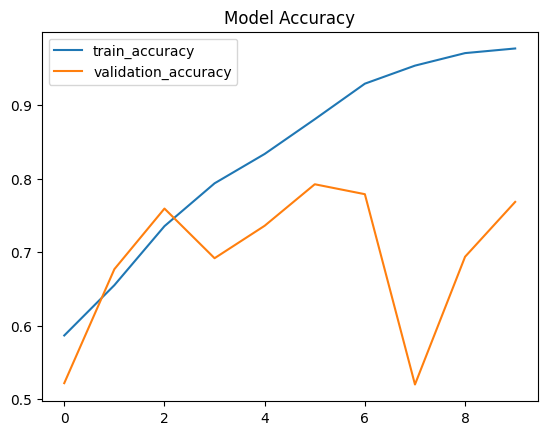

In [23]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='validation_accuracy')
plt.title('Model Accuracy')
plt.legend()

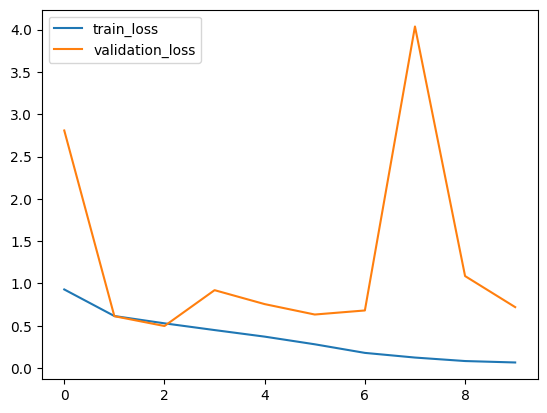

In [24]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='validation_loss')
plt.legend()
plt.show()

In [14]:
# to reduce the overfittig

# Add more data
# Data augmentation
# L1/L2 regularization
# Dropout
# Batch normalization
# Reduce model complexity

In [3]:
import cv2

In [1]:
test_image_path = '/content/drive/MyDrive/cat.png'  

In [4]:
test_image=cv2.imread(test_image_path)

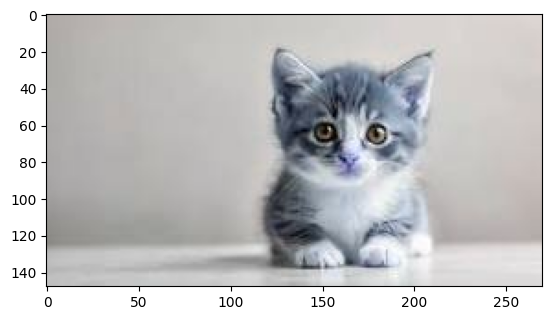

In [7]:
import matplotlib.pyplot as plt
plt.imshow(test_image)
plt.show()

In [8]:
test_image.shape

(148, 270, 3)

In [9]:
test_image=cv2.resize(test_image,(256,256))
test_image.shape

(256, 256, 3)

In [10]:
test_input=test_image.reshape(1,256,256,3)

In [12]:
model.predict(test_input)

NameError: name 'model' is not defined